In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Upload do arquivo
from google.colab import files
uploaded = files.upload()

# Ler o arquivo (ajuste o nome se necessário)
df = pd.read_excel('PREÇO DO OURO ALL TIME REAL.xlsx')

df.head()

Saving PREÇO DO OURO ALL TIME REAL.xlsx to PREÇO DO OURO ALL TIME REAL.xlsx


,data,tipo,compra,venda
0,2026-02-27,A,867.2562,867.3573
1,2026-02-26,A,855.6962,855.7961
2,2026-02-25,A,858.8078,858.9080
3,2026-02-24,A,855.1382,855.2375
4,2026-02-23,A,859.6237,859.7236


In [2]:
# Converter coluna de data (ajuste o nome da coluna)
df['data'] = pd.to_datetime(df['data'])

# Ordenar por data
df = df.sort_values(by='data')

# Criar colunas auxiliares
df['Ano'] = df['data'].dt.year
df['Mes'] = df['data'].dt.month

# Garantir que o preço seja numérico
df['Preco'] = pd.to_numeric(df['compra'], errors='coerce') # Assuming 'compra' or 'venda' is intended as price

# Remover valores nulos
df = df.dropna()

df.head()

,data,tipo,compra,venda,Ano,Mes,Preco
7946,1994-07-01,A,10.7274,13.2452,1994,7,10.7274
7945,1994-07-04,A,11.5043,11.6285,1994,7,11.5043
7944,1994-07-05,A,11.3528,11.4756,1994,7,11.3528
7943,1994-07-06,A,11.2451,11.3698,1994,7,11.2451
7942,1994-07-07,A,11.1986,11.3218,1994,7,11.1986


In [3]:
# Média anual
preco_anual = df.groupby('Ano')['Preco'].mean().reset_index()

# Crescimento percentual ano a ano
preco_anual['Crescimento_%'] = preco_anual['Preco'].pct_change() * 100

preco_anual


,Ano,Preco,Crescimento_%
0,1994,10.717081,NaN
1,1995,11.257149,5.039320
2,1996,12.490781,10.958657
3,1997,11.511449,-7.840443
4,1998,11.115594,-3.438789
5,1999,16.424200,47.758184
6,2000,17.169983,4.540756
7,2001,20.906570,21.762323
8,2002,29.477494,40.996318
9,2003,35.629311,20.869537


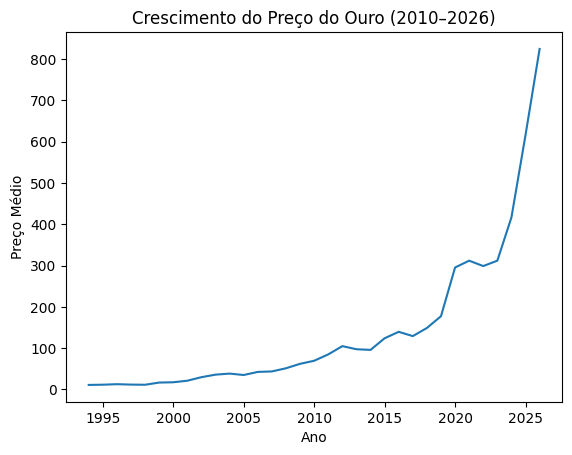

In [4]:
plt.figure()
plt.plot(preco_anual['Ano'], preco_anual['Preco'])

plt.title('Crescimento do Preço do Ouro (2010–2026)')
plt.xlabel('Ano')
plt.ylabel('Preço Médio')
plt.show()

In [5]:
max_min_anual = df.groupby('Ano')['Preco'].agg(['max', 'min']).reset_index()
max_min_anual.columns = ['Ano', 'Preco_Max', 'Preco_Min']

max_min_anual

,Ano,Preco_Max,Preco_Min
0,1994,11.6069,10.16230
1,1995,12.0878,9.98248
2,1996,13.0486,12.08760
3,1997,12.2301,10.25680
4,1998,11.6703,10.18740
5,1999,20.4386,11.30090
6,2000,18.1741,15.94590
7,2001,25.8360,17.26160
8,2002,39.4906,21.49840
9,2003,43.1152,30.95260


In [6]:
# Agrupar por ano e mês
min_max_mensal = df.groupby(['Ano', 'Mes'])['Preco'].agg(['min', 'max']).reset_index()

# Renomear colunas
min_max_mensal.columns = ['Ano', 'Mes', 'Preco_Min', 'Preco_Max']

min_max_mensal['Data_Mensal'] = pd.to_datetime(
    min_max_mensal['Ano'].astype(str) + '-' + min_max_mensal['Mes'].astype(str) + '-01'
)

min_max_mensal = min_max_mensal.sort_values('Data_Mensal')

# Adicionar o nome do mês
min_max_mensal['Mes_Nome'] = min_max_mensal['Data_Mensal'].dt.month_name()

# Variação percentual do preço mínimo
min_max_mensal['Var_Min_%'] = min_max_mensal['Preco_Min'].pct_change() * 100

# Variação percentual do preço máximo
min_max_mensal['Var_Max_%'] = min_max_mensal['Preco_Max'].pct_change() * 100

def classificar(x):
    if pd.isna(x):
        return 'Sem referência'
    elif x > 0:
        return 'Aumento'
    elif x < 0:
        return 'Queda'
    else:
        return 'Estável'

min_max_mensal['Status_Min'] = min_max_mensal['Var_Min_%'].apply(classificar)
min_max_mensal['Status_Max'] = min_max_mensal['Var_Max_%'].apply(classificar)

tabela_min_max_variacao = min_max_mensal[
    ['Ano', 'Mes', 'Mes_Nome',
     'Preco_Min', 'Var_Min_%', 'Status_Min',
     'Preco_Max', 'Var_Max_%', 'Status_Max']
]

tabela_min_max_variacao


,Ano,Mes,Mes_Nome,Preco_Min,Var_Min_%,Status_Min,Preco_Max,Var_Max_%,Status_Max
0,1994,7,July,10.7274,NaN,Sem referência,11.6069,NaN,Sem referência
1,1994,8,August,10.7400,0.117456,Aumento,11.3729,-2.016042,Queda
2,1994,9,September,10.6208,-1.109870,Queda,10.9861,-3.401067,Queda
3,1994,10,October,10.2834,-3.176785,Queda,10.6830,-2.758941,Queda
4,1994,11,November,10.2130,-0.684598,Queda,10.5073,-1.644669,Queda
...,...,...,...,...,...,...,...,...,...
375,2025,10,October,658.7329,8.504592,Aumento,750.8030,14.328739,Aumento
376,2025,11,November,684.6656,3.936755,Aumento,720.6053,-4.022054,Queda
377,2025,12,December,716.2608,4.614691,Aumento,810.2808,12.444469,Aumento
378,2026,1,January,757.6087,5.772744,Aumento,879.5520,8.549036,Aumento


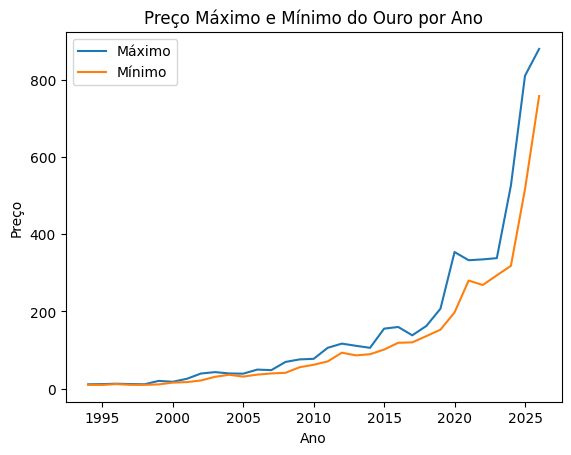

In [7]:
plt.figure()
plt.plot(max_min_anual['Ano'], max_min_anual['Preco_Max'], label='Máximo')
plt.plot(max_min_anual['Ano'], max_min_anual['Preco_Min'], label='Mínimo')

plt.title('Preço Máximo e Mínimo do Ouro por Ano')
plt.xlabel('Ano')
plt.ylabel('Preço')
plt.legend()
plt.show()

In [8]:
import pandas as pd

# Garantir datetime
df['data'] = pd.to_datetime(df['data'])

# Criar colunas auxiliares
df['AnoMes'] = df['data'].dt.to_period('M')
df['Mes'] = df['data'].dt.month

# Garantir que os preços são numéricos
df['Abertura'] = pd.to_numeric(df['compra'], errors='coerce') # Changed from 'abertura' to 'compra'
df['Fechamento'] = pd.to_numeric(df['venda'], errors='coerce') # Changed from 'fechamento' to 'venda'

# Ordenar por data
df = df.sort_values('data')

# Criar tabela mensal com abertura (primeiro do mês) e fechamento (último do mês)
mensal = df.groupby('AnoMes').agg({
    'Abertura': 'first',
    'Fechamento': 'last'
}).reset_index()

# Extrair mês (1 a 12)
mensal['Mes'] = mensal['AnoMes'].dt.month

# Calcular média histórica por mês
media_mensal = mensal.groupby('Mes').agg({
    'Abertura': 'mean',
    'Fechamento': 'mean'
}).reset_index()

# Opcional: ordenar corretamente (jan → dez)
media_mensal = media_mensal.sort_values('Mes')

media_mensal

,Mes,Abertura,Fechamento
0,1,134.073322,138.004844
1,2,135.903450,139.261912
2,3,116.549787,119.280555
3,4,119.042981,121.293135
4,5,121.430026,122.738245
5,6,123.186510,121.367597
6,7,117.940525,120.361000
7,8,120.668259,124.111106
8,9,124.035309,126.789087
9,10,126.820587,129.503059


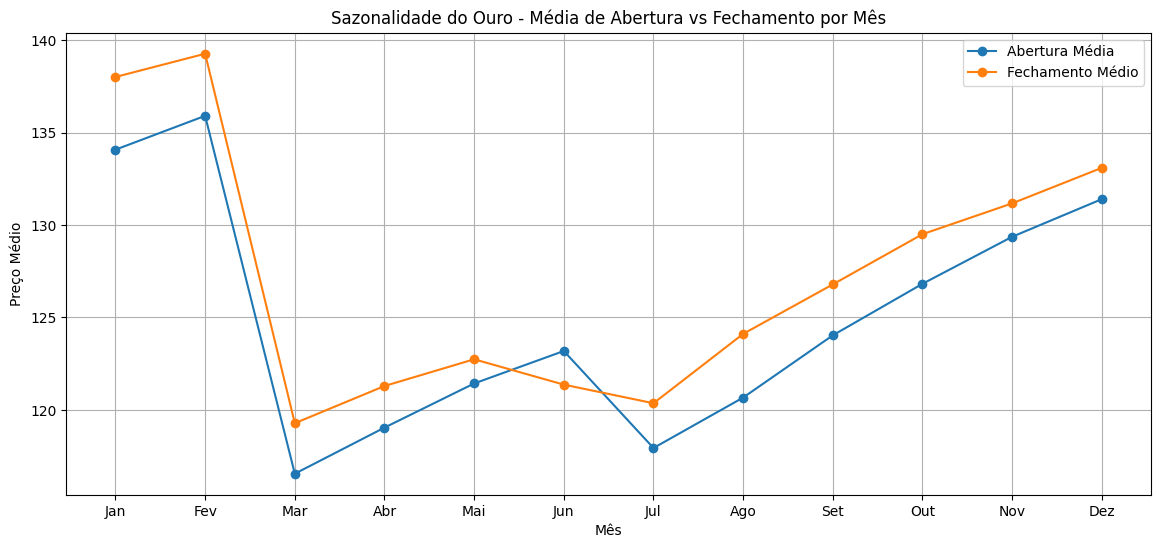

In [9]:
import matplotlib.pyplot as plt

# Mapear nomes dos meses para melhor visualização
meses_nome = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

media_mensal['Mes_Nome'] = media_mensal['Mes'].map(meses_nome)

# Ordenar corretamente
media_mensal = media_mensal.sort_values('Mes')

# Plot
plt.figure(figsize=(14,6))

plt.plot(media_mensal['Mes_Nome'], media_mensal['Abertura'], marker='o', label='Abertura Média')
plt.plot(media_mensal['Mes_Nome'], media_mensal['Fechamento'], marker='o', label='Fechamento Médio')

plt.title('Sazonalidade do Ouro - Média de Abertura vs Fechamento por Mês')
plt.xlabel('Mês')
plt.ylabel('Preço Médio')
plt.legend()
plt.grid()

plt.show()


In [10]:
preco_anual['Variacao_Anual_%'] = preco_anual['Preco'].pct_change() * 100

preco_anual

,Ano,Preco,Crescimento_%,Variacao_Anual_%
0,1994,10.717081,NaN,NaN
1,1995,11.257149,5.039320,5.039320
2,1996,12.490781,10.958657,10.958657
3,1997,11.511449,-7.840443,-7.840443
4,1998,11.115594,-3.438789,-3.438789
5,1999,16.424200,47.758184,47.758184
6,2000,17.169983,4.540756,4.540756
7,2001,20.906570,21.762323,21.762323
8,2002,29.477494,40.996318,40.996318
9,2003,35.629311,20.869537,20.869537


In [11]:
# Min, max e amplitude
base = df.groupby('Ano')['Preco'].agg(['min', 'max', 'mean']).reset_index()

base['Amplitude'] = base['max'] - base['min']
base['Variacao_%'] = base['mean'].pct_change() * 100

# Ordenar pela maior oscilação
ranking = base.sort_values(by='Variacao_%', ascending=False)

ranking

,Ano,min,max,mean,Amplitude,Variacao_%
26,2020,197.67450,353.9230,295.217498,156.24850,66.609538
31,2025,516.89360,810.2808,616.255467,293.38720,47.949156
5,1999,11.30090,20.4386,16.424200,9.13770,47.758184
8,2002,21.49840,39.4906,29.477494,17.99220,40.996318
32,2026,757.60870,879.5520,824.945464,121.94330,33.864202
30,2024,318.25180,526.3002,416.531925,208.04840,33.592736
21,2015,101.51960,155.6289,123.760988,54.10930,29.489571
18,2012,93.44110,116.8841,104.723484,23.44300,23.693621
17,2011,70.87360,106.0714,84.663609,35.19780,22.249562
7,2001,17.26160,25.8360,20.906570,8.57440,21.762323


In [12]:
# Base mensal completa
base_mensal = df.groupby(['Ano', 'Mes'])['Preco'].agg(['min', 'max', 'mean']).reset_index()

# Criar data
base_mensal['Data_Mensal'] = pd.to_datetime(
    base_mensal['Ano'].astype(str) + '-' + base_mensal['Mes'].astype(str) + '-01'
)

# Ordenar
base_mensal = base_mensal.sort_values('Data_Mensal')

# Métricas
base_mensal['Amplitude'] = base_mensal['max'] - base_mensal['min']
base_mensal['Variacao_%'] = base_mensal['mean'].pct_change() * 100

# Nome do mês
base_mensal['Mes_Nome'] = base_mensal['Data_Mensal'].dt.strftime('%B')

# Ranking final (por maior oscilação)
ranking_final = base_mensal.sort_values(by='Variacao_%', ascending=False)

ranking_final[['Ano', 'Mes', 'Mes_Nome', 'min', 'max', 'Amplitude', 'Variacao_%']]

,Ano,Mes,Mes_Nome,min,max,Amplitude,Variacao_%
55,1999,2,February,16.3689,19.0066,2.6377,25.402412
54,1999,1,January,11.3009,18.7927,7.4918,23.599219
63,1999,10,October,18.6511,20.4386,1.7875,19.193222
171,2008,10,October,49.6781,69.4707,19.7926,17.109234
309,2020,4,April,268.0256,310.8031,42.7775,15.448616
...,...,...,...,...,...,...,...
256,2015,11,November,127.0972,137.5180,10.4208,-9.057662
169,2008,8,August,41.3205,45.7226,4.4021,-9.731255
57,1999,4,April,15.3229,15.9866,0.6637,-11.382780
105,2003,4,April,31.1778,35.7379,4.5601,-12.169637


In [13]:
tabela_ano_mes = (
    df.pivot_table(
        values='Preco',
        index='Ano',
        columns='Mes',
        aggfunc='mean'
    )
    .rename(columns={
        1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
        5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
        9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
    })
    .sort_index()
)

tabela_ano_mes

Mes,Jan,Fev,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
Ano,,,,,,,,,,,,
1994,NaN,NaN,NaN,NaN,NaN,NaN,11.385633,10.899209,10.807486,10.530632,10.324635,10.320009
1995,10.263705,10.104786,10.837283,11.334418,11.059091,11.314114,11.444152,11.478643,11.648445,11.750252,11.862570,11.996735
1996,12.456305,12.739168,12.523019,12.488010,12.513091,12.377300,12.381574,12.592182,12.508762,12.529868,12.495470,12.301857
1997,11.889827,11.707306,11.937726,11.759938,11.861895,11.864162,11.374470,11.436843,11.396759,11.542717,11.016740,10.458368
1998,10.565043,10.897178,10.891286,11.447247,11.184825,11.024405,11.066822,10.840976,11.160105,11.474019,11.443970,11.411795
1999,14.104890,17.687872,17.629643,15.622900,15.173529,15.078410,15.043909,15.625641,16.367495,19.508945,18.320125,17.084091
2000,16.752152,17.349290,16.286295,16.521147,16.960345,17.536114,17.486152,16.971961,17.462635,17.265657,17.518120,17.965365
2001,17.708082,17.603794,18.093864,18.772300,20.499518,21.444075,21.735005,21.858365,23.998895,24.586359,22.747315,21.703845
2002,22.563709,23.270756,22.458305,23.092355,25.350229,27.987590,30.400513,31.578968,33.621824,37.626374,36.074695,38.396119


In [14]:
tabela_var_yoy_formatada = (
    tabela_ano_mes.pct_change() * 100
).round(1)

tabela_var_yoy_formatada

/tmp/ipykernel_35464/1164844344.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  tabela_ano_mes.pct_change() * 100


Mes,Jan,Fev,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
Ano,,,,,,,,,,,,
1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995,NaN,NaN,NaN,NaN,NaN,NaN,0.5,5.3,7.8,11.6,14.9,16.2
1996,21.4,26.1,15.6,10.2,13.1,9.4,8.2,9.7,7.4,6.6,5.3,2.5
1997,-4.5,-8.1,-4.7,-5.8,-5.2,-4.1,-8.1,-9.2,-8.9,-7.9,-11.8,-15.0
1998,-11.1,-6.9,-8.8,-2.7,-5.7,-7.1,-2.7,-5.2,-2.1,-0.6,3.9,9.1
1999,33.5,62.3,61.9,36.5,35.7,36.8,35.9,44.1,46.7,70.0,60.1,49.7
2000,18.8,-1.9,-7.6,5.7,11.8,16.3,16.2,8.6,6.7,-11.5,-4.4,5.2
2001,5.7,1.5,11.1,13.6,20.9,22.3,24.3,28.8,37.4,42.4,29.9,20.8
2002,27.4,32.2,24.1,23.0,23.7,30.5,39.9,44.5,40.1,53.0,58.6,76.9


In [15]:
tabela_var_mensal = (tabela_ano_mes.pct_change(axis=1) * 100).round(1)

tabela_var_mensal.style\
    .format("{:.1f}%")\
    .applymap(
        lambda x: 'color: blue' if x > 0 else ('color: red' if x < 0 else '')
    )


/tmp/ipykernel_35464/2876343288.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  tabela_var_mensal = (tabela_ano_mes.pct_change(axis=1) * 100).round(1)
/tmp/ipykernel_35464/2876343288.py:5: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(


Mes,Jan,Fev,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
Ano,,,,,,,,,,,,
1994,nan%,nan%,nan%,nan%,nan%,nan%,nan%,-4.3%,-0.8%,-2.6%,-2.0%,-0.0%
1995,nan%,-1.5%,7.2%,4.6%,-2.4%,2.3%,1.1%,0.3%,1.5%,0.9%,1.0%,1.1%
1996,nan%,2.3%,-1.7%,-0.3%,0.2%,-1.1%,0.0%,1.7%,-0.7%,0.2%,-0.3%,-1.5%
1997,nan%,-1.5%,2.0%,-1.5%,0.9%,0.0%,-4.1%,0.5%,-0.4%,1.3%,-4.6%,-5.1%
1998,nan%,3.1%,-0.1%,5.1%,-2.3%,-1.4%,0.4%,-2.0%,2.9%,2.8%,-0.3%,-0.3%
1999,nan%,25.4%,-0.3%,-11.4%,-2.9%,-0.6%,-0.2%,3.9%,4.7%,19.2%,-6.1%,-6.7%
2000,nan%,3.6%,-6.1%,1.4%,2.7%,3.4%,-0.3%,-2.9%,2.9%,-1.1%,1.5%,2.6%
2001,nan%,-0.6%,2.8%,3.7%,9.2%,4.6%,1.4%,0.6%,9.8%,2.4%,-7.5%,-4.6%
2002,nan%,3.1%,-3.5%,2.8%,9.8%,10.4%,8.6%,3.9%,6.5%,11.9%,-4.1%,6.4%


/tmp/ipykernel_35464/3934470970.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  tabela_var_mensal = (tabela_ano_mes.pct_change(axis=1) * 100).round(1)


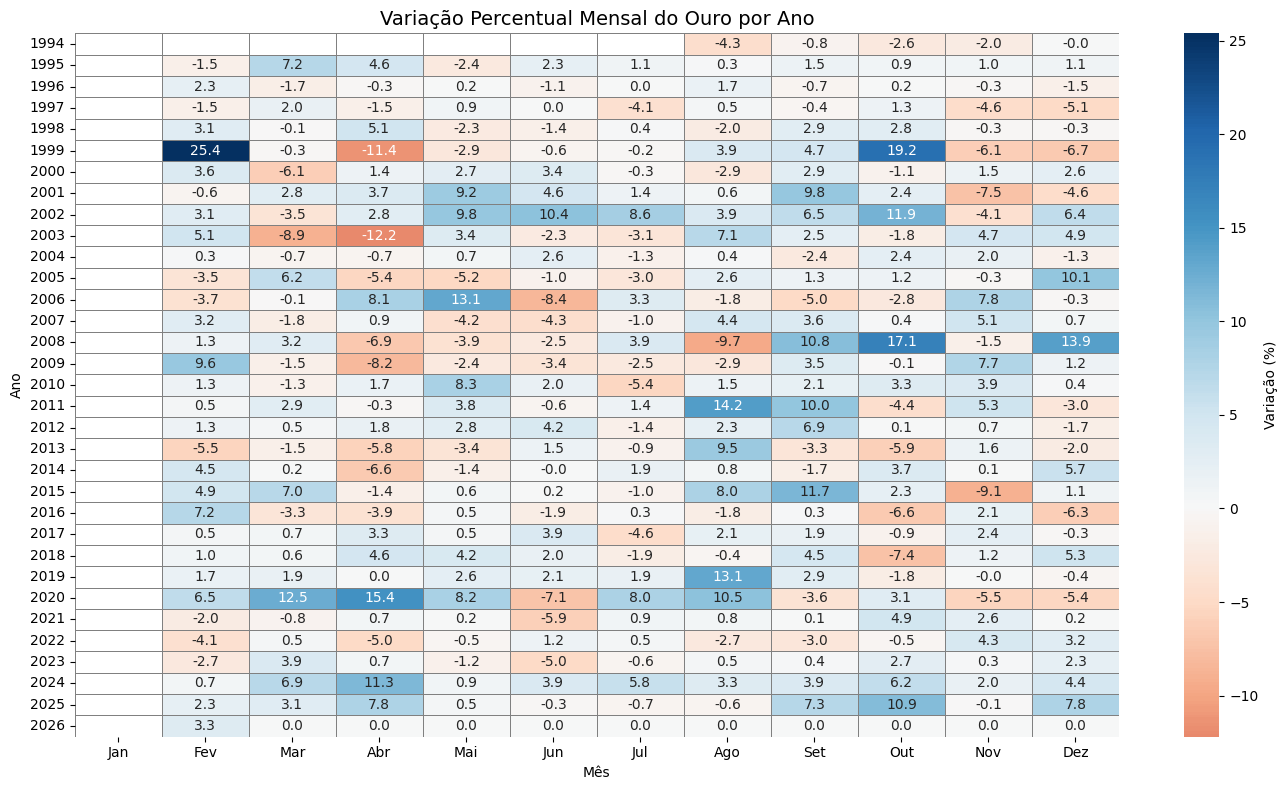

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcula variação percentual mês a mês dentro do ano
tabela_var_mensal = (tabela_ano_mes.pct_change(axis=1) * 100).round(1)

# Configuração da figura
plt.figure(figsize=(14, 8))

# Heatmap
sns.heatmap(
    tabela_var_mensal,
    annot=True,              # mostra os valores
    fmt=".1f",               # 1 casa decimal
    cmap="RdBu",             # vermelho (queda) → azul (alta)
    center=0,                # zero como ponto neutro
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Variação (%)'}
)

# Títulos e labels
plt.title("Variação Percentual Mensal do Ouro por Ano", fontsize=14)
plt.xlabel("Mês")
plt.ylabel("Ano")

plt.tight_layout()
plt.show()


/tmp/ipykernel_35464/1751905689.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  tabela_var_mensal = (tabela_var_mensal.pct_change(axis=1) * 100)


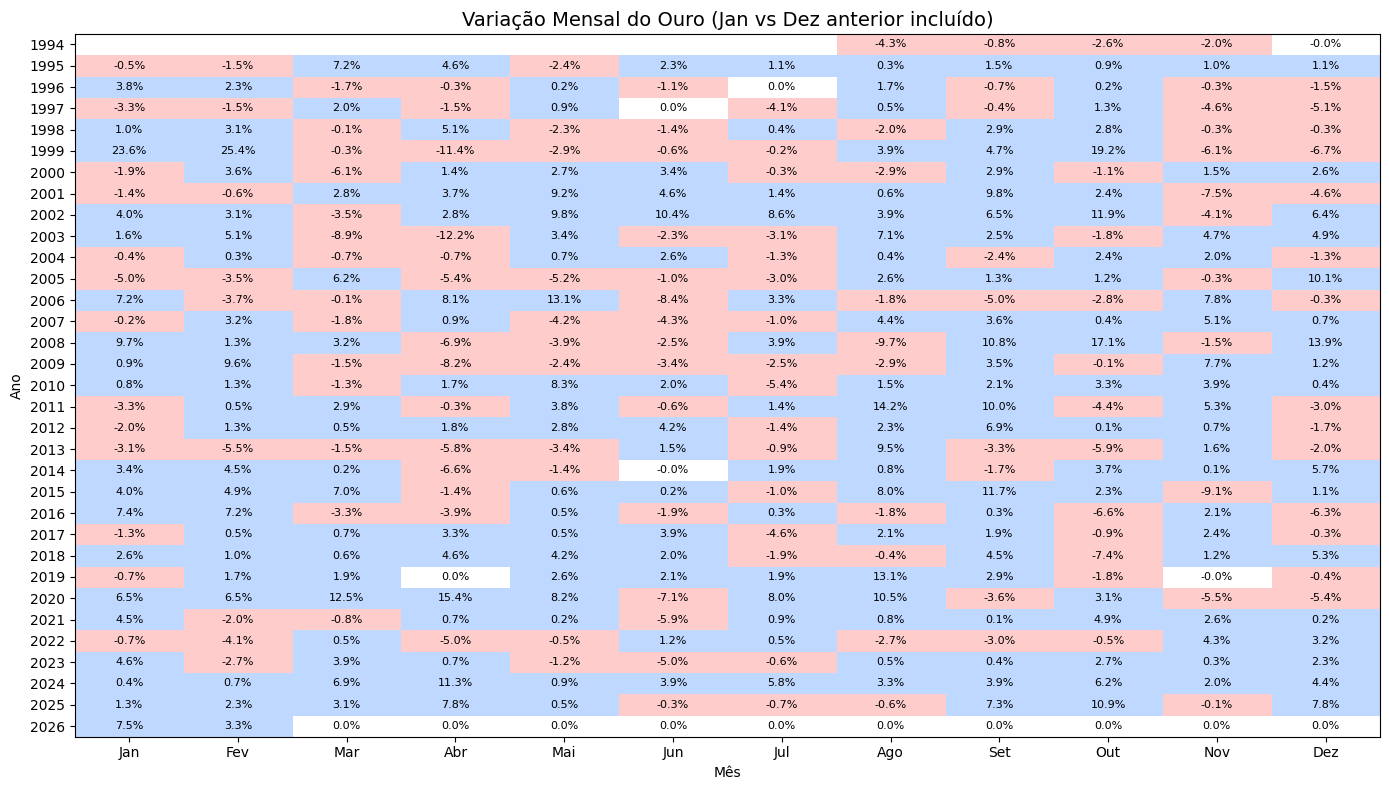

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Copiar tabela original
tabela_var_mensal = tabela_ano_mes.copy()

# Calcular variação mês a mês
tabela_var_mensal = (tabela_var_mensal.pct_change(axis=1) * 100)

# Corrigir Janeiro: comparar com Dezembro do ano anterior
tabela_var_mensal['Jan'] = (
    (tabela_ano_mes['Jan'] / tabela_ano_mes['Dez'].shift(1) - 1) * 100
)

# Arredondar
tabela_var_mensal = tabela_var_mensal.round(1)

# =========================
# CORES SUAVES
# =========================

cores = np.zeros(tabela_var_mensal.shape + (3,))

for i in range(tabela_var_mensal.shape[0]):
    for j in range(tabela_var_mensal.shape[1]):
        valor = tabela_var_mensal.iloc[i, j]

        if np.isnan(valor):
            cores[i, j] = [1, 1, 1]  # branco

        elif valor > 0:
            cores[i, j] = [0.75, 0.85, 1.00]  # azul suave

        elif valor < 0:
            cores[i, j] = [1.00, 0.80, 0.80]  # vermelho suave

        else:
            cores[i, j] = [1, 1, 1]

# =========================
# PLOT
# =========================

plt.figure(figsize=(14, 8))
plt.imshow(cores, aspect='auto')

# Inserir valores
for i in range(tabela_var_mensal.shape[0]):
    for j in range(tabela_var_mensal.shape[1]):
        valor = tabela_var_mensal.iloc[i, j]
        if not np.isnan(valor):
            plt.text(j, i, f"{valor:.1f}%", ha='center', va='center', fontsize=8)

# Eixos
plt.xticks(range(len(tabela_var_mensal.columns)), tabela_var_mensal.columns)
plt.yticks(range(len(tabela_var_mensal.index)), tabela_var_mensal.index)

plt.title("Variação Mensal do Ouro (Jan vs Dez anterior incluído)", fontsize=14)
plt.xlabel("Mês")
plt.ylabel("Ano")

plt.grid(False)
plt.tight_layout()
plt.show()


In [18]:
soma_total = tabela_var_mensal.sum(axis=0).to_frame().T

soma_total


Mes,Jan,Fev,Mar,Abr,Mai,Jun,Jul,Ago,Set,Out,Nov,Dez
0,71.0,67.6,30.5,4.3,43.3,-1.5,7.4,62.9,81.1,61.1,14.9,32.4


/tmp/ipykernel_35464/468812321.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  tabela_var_mensal = (tabela_filtrada.pct_change(axis=1) * 100)


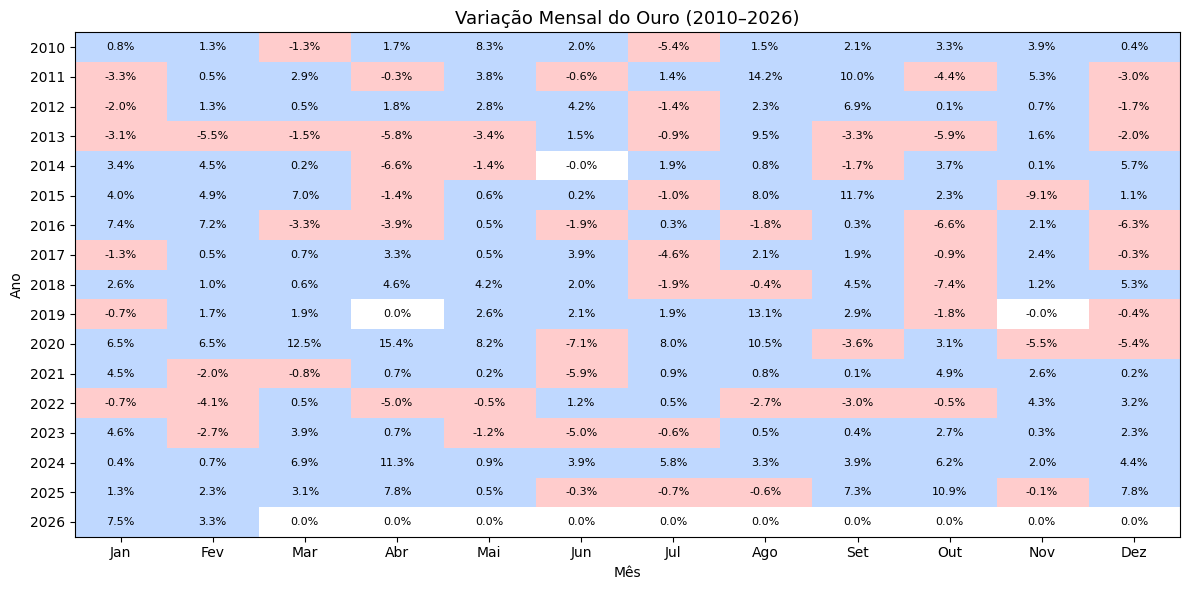

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# FILTRO DE ANOS
# =========================

tabela_filtrada = tabela_ano_mes.loc[2010:2026].copy()

# =========================
# CÁLCULO DAS VARIAÇÕES
# =========================

tabela_var_mensal = (tabela_filtrada.pct_change(axis=1) * 100)

# Corrigir Janeiro (vs Dez do ano anterior)
tabela_var_mensal['Jan'] = (
    (tabela_filtrada['Jan'] / tabela_ano_mes['Dez'].shift(1) - 1) * 100
)

# Arredondar
tabela_var_mensal = tabela_var_mensal.round(1)

# =========================
# CORES SUAVES
# =========================

cores = np.zeros(tabela_var_mensal.shape + (3,))

for i in range(tabela_var_mensal.shape[0]):
    for j in range(tabela_var_mensal.shape[1]):
        valor = tabela_var_mensal.iloc[i, j]

        if np.isnan(valor):
            cores[i, j] = [1, 1, 1]
        elif valor > 0:
            cores[i, j] = [0.75, 0.85, 1.00]
        elif valor < 0:
            cores[i, j] = [1.00, 0.80, 0.80]
        else:
            cores[i, j] = [1, 1, 1]

# =========================
# PLOT
# =========================

plt.figure(figsize=(12, 6))
plt.imshow(cores, aspect='auto')

# Inserir valores
for i in range(tabela_var_mensal.shape[0]):
    for j in range(tabela_var_mensal.shape[1]):
        valor = tabela_var_mensal.iloc[i, j]
        if not np.isnan(valor):
            plt.text(j, i, f"{valor:.1f}%", ha='center', va='center', fontsize=8)

# Eixos
plt.xticks(range(len(tabela_var_mensal.columns)), tabela_var_mensal.columns)
plt.yticks(range(len(tabela_var_mensal.index)), tabela_var_mensal.index)

plt.title("Variação Mensal do Ouro (2010–2026)", fontsize=13)
plt.xlabel("Mês")
plt.ylabel("Ano")

plt.tight_layout()
plt.show()


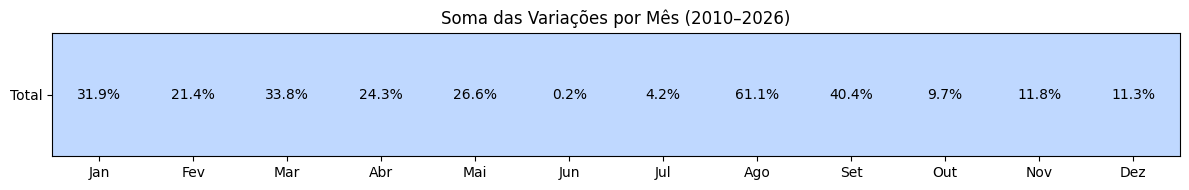

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# SOMA DO PERÍODO
# =========================

soma_total_periodo = tabela_var_mensal.sum(axis=0).round(1).to_frame().T

# =========================
# CORES SUAVES
# =========================

cores = np.zeros(soma_total_periodo.shape + (3,))

for j in range(soma_total_periodo.shape[1]):
    valor = soma_total_periodo.iloc[0, j]

    if np.isnan(valor):
        cores[0, j] = [1, 1, 1]  # branco

    elif valor > 0:
        cores[0, j] = [0.75, 0.85, 1.0]  # azul suave

    elif valor < 0:
        cores[0, j] = [1.0, 0.8, 0.8]  # vermelho suave

    else:
        cores[0, j] = [1, 1, 1]

# =========================
# PLOT
# =========================

plt.figure(figsize=(12, 2))
plt.imshow(cores, aspect='auto')

# Inserir valores
for j in range(soma_total_periodo.shape[1]):
    valor = soma_total_periodo.iloc[0, j]
    if not np.isnan(valor):
        plt.text(j, 0, f"{valor:.1f}%", ha='center', va='center', fontsize=10)

# Eixos
plt.xticks(range(len(soma_total_periodo.columns)), soma_total_periodo.columns)
plt.yticks([0], ['Total'])

plt.title("Soma das Variações por Mês (2010–2026)", fontsize=12)

plt.grid(False)
plt.tight_layout()
plt.show()


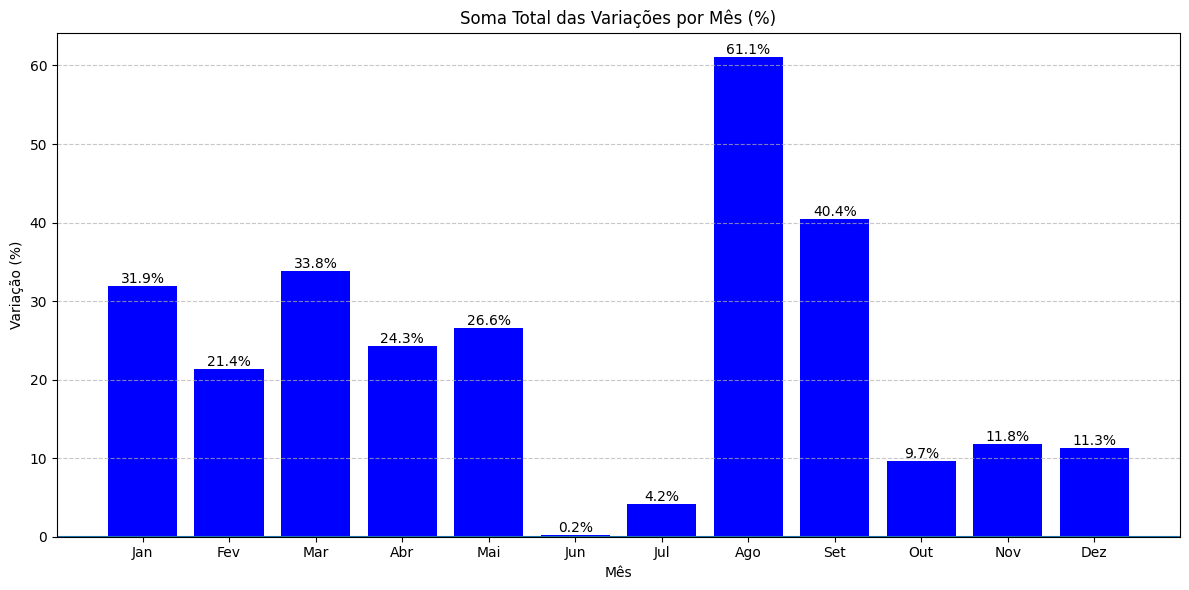

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Garantir soma total
soma_total = tabela_var_mensal.sum(axis=0).round(1)

# Criar cores baseadas no valor
cores = []

for valor in soma_total:
    if np.isnan(valor):
        cores.append('gray')
    elif valor > 0:
        cores.append('blue')
    elif valor < 0:
        cores.append('red')
    else:
        cores.append('black')

# Plot
plt.figure(figsize=(12,6))

barras = plt.bar(soma_total.index, soma_total.values, color=cores)

# Inserir valores acima/abaixo das barras
for i, valor in enumerate(soma_total.values):
    if not np.isnan(valor):
        if valor >= 0:
            plt.text(i, valor, f"{valor:.1f}%", ha='center', va='bottom')
        else:
            plt.text(i, valor, f"{valor:.1f}%", ha='center', va='top')

# Linha zero (fundamental para leitura)
plt.axhline(0)

# Labels
plt.title("Soma Total das Variações por Mês (%)")
plt.xlabel("Mês")
plt.ylabel("Variação (%)")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

ELEIÇÕES

In [22]:
anos_eleicao = [
    1998, 2002, 2006, 2010, 2014, 2018, 2022
]


In [23]:
anos_eleicao.append(2026)


In [24]:
tabela_eleicao = tabela_var_mensal.loc[
    tabela_var_mensal.index.intersection(anos_eleicao)
].copy()


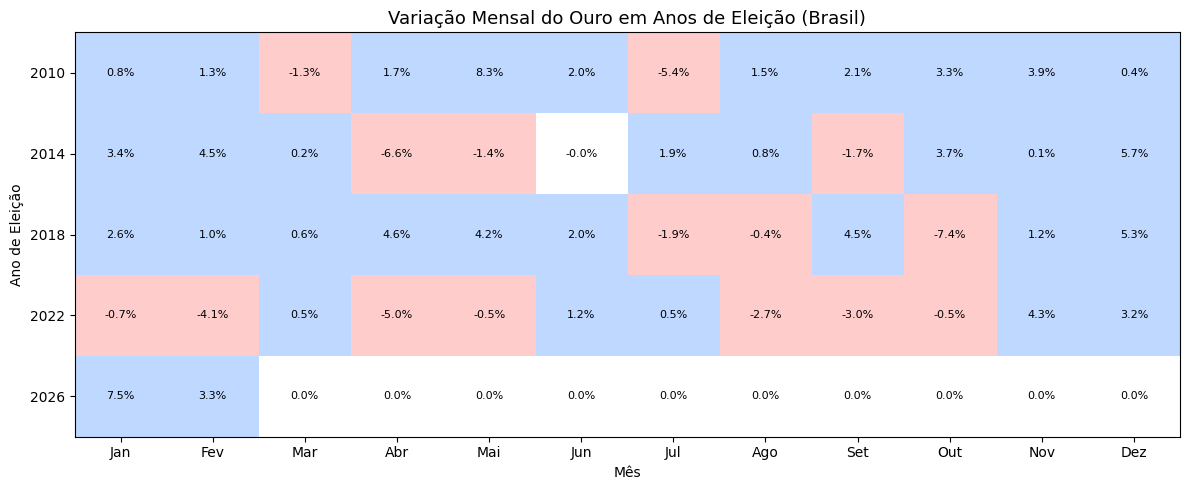

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Criar matriz de cores
cores = np.zeros(tabela_eleicao.shape + (3,))

for i in range(tabela_eleicao.shape[0]):
    for j in range(tabela_eleicao.shape[1]):
        valor = tabela_eleicao.iloc[i, j]

        if np.isnan(valor):
            cores[i, j] = [1, 1, 1]
        elif valor > 0:
            cores[i, j] = [0.75, 0.85, 1.0]  # azul suave
        elif valor < 0:
            cores[i, j] = [1.0, 0.8, 0.8]   # vermelho suave
        else:
            cores[i, j] = [1, 1, 1]

# Plot
plt.figure(figsize=(12, 5))
plt.imshow(cores, aspect='auto')

# Inserir valores
for i in range(tabela_eleicao.shape[0]):
    for j in range(tabela_eleicao.shape[1]):
        valor = tabela_eleicao.iloc[i, j]
        if not np.isnan(valor):
            plt.text(j, i, f"{valor:.1f}%", ha='center', va='center', fontsize=8)

# Eixos
plt.xticks(range(len(tabela_eleicao.columns)), tabela_eleicao.columns)
plt.yticks(range(len(tabela_eleicao.index)), tabela_eleicao.index)

plt.title("Variação Mensal do Ouro em Anos de Eleição (Brasil)", fontsize=13)
plt.xlabel("Mês")
plt.ylabel("Ano de Eleição")

plt.tight_layout()
plt.show()


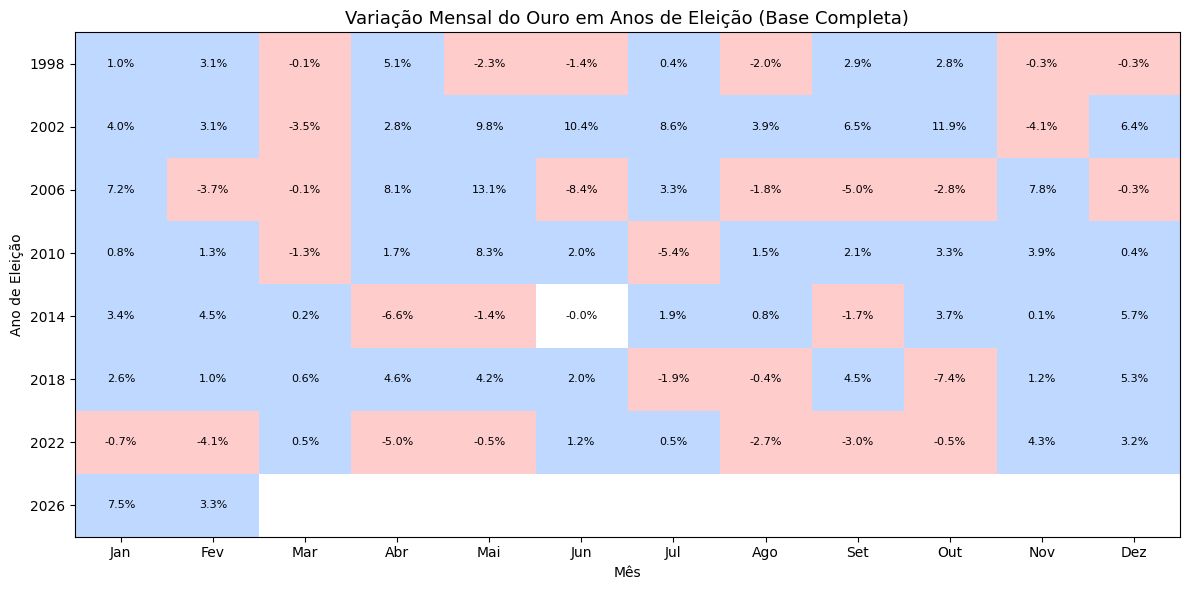

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# LISTA DE ANOS DE ELEIÇÃO
# =========================

anos_eleicao = [
    1998, 2002, 2006, 2010, 2014, 2018, 2022, 2026
]

# =========================
# CALCULAR VARIAÇÕES MENSAIS PARA A BASE COMPLETA PRIMEIRO
# =========================

# Start with the full tabela_ano_mes
# The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version.
# I'll specify 'fill_method=None' to explicitly not fill NA values.
full_tabela_var_mensal = (tabela_ano_mes.pct_change(axis=1, fill_method=None) * 100)

# Correct January (vs December of previous year) for the full table
full_tabela_var_mensal['Jan'] = (
    (tabela_ano_mes['Jan'] / tabela_ano_mes['Dez'].shift(1) - 1) * 100
)

# Arredondar
full_tabela_var_mensal = full_tabela_var_mensal.round(1)

# =========================
# FILTRAR ANOS DE ELEIÇÃO DA TABELA DE VARIAÇÃO COMPLETA
# =========================

tabela_eleicao = full_tabela_var_mensal.loc[
    full_tabela_var_mensal.index.intersection(anos_eleicao)
].copy()

# =========================
# CORES SUAVES
# =========================

cores = np.zeros(tabela_eleicao.shape + (3,))

for i in range(tabela_eleicao.shape[0]):
    for j in range(tabela_eleicao.shape[1]):
        valor = tabela_eleicao.iloc[i, j]

        if np.isnan(valor):
            cores[i, j] = [1, 1, 1]
        elif valor > 0:
            cores[i, j] = [0.75, 0.85, 1.0]  # azul suave
        elif valor < 0:
            cores[i, j] = [1.0, 0.8, 0.8]   # vermelho suave
        else:
            cores[i, j] = [1, 1, 1]

# =========================
# PLOT
# =========================

plt.figure(figsize=(12, 6))
plt.imshow(cores, aspect='auto')

# Inserir valores
for i in range(tabela_eleicao.shape[0]):
    for j in range(tabela_eleicao.shape[1]):
        valor = tabela_eleicao.iloc[i, j]
        if not np.isnan(valor):
            plt.text(j, i, f"{valor:.1f}%", ha='center', va='center', fontsize=8)

# Eixos
plt.xticks(range(len(tabela_eleicao.columns)), tabela_eleicao.columns)
plt.yticks(range(len(tabela_eleicao.index)), tabela_eleicao.index)

plt.title("Variação Mensal do Ouro em Anos de Eleição (Base Completa)", fontsize=13)
plt.xlabel("Mês")
plt.ylabel("Ano de Eleição")

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

# Carregar base
df = pd.read_excel("PREÇO DO OURO ALL TIME REAL.xlsx")

# Ajustar nomes conforme seu dataset
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data')

# Criar colunas auxiliares
df['Ano'] = df['data'].dt.year
df['Mes'] = df['data'].dt.month

# Garantir que o preço seja numérico (recriar a coluna 'Preco')
df['Preco'] = pd.to_numeric(df['compra'], errors='coerce')

# Criar série mensal (pegando último valor do mês)
df_mensal = df.resample('ME', on='data').last().reset_index()

# Recriar ano/mês após resample
df_mensal['Ano'] = df_mensal['data'].dt.year
df_mensal['Mes'] = df_mensal['data'].dt.month

In [28]:
df_mensal['Variacao'] = df_mensal['Preco'].pct_change() * 100

In [29]:
def gerar_tabela(inicio, fim):
    df_filtrado = df_mensal[(df_mensal['Ano'] >= inicio) & (df_mensal['Ano'] <= fim)]

    tabela = df_filtrado.pivot(index='Ano', columns='Mes', values='Variacao')

    # Ordenar meses corretamente
    tabela = tabela.reindex(columns=range(1,13))

    return tabela.round(2)


In [30]:
tabela_1 = gerar_tabela(2010, 2013)
tabela_2 = gerar_tabela(2014, 2017)
tabela_3 = gerar_tabela(2018, 2021)
tabela_4 = gerar_tabela(2022, 2025)


In [31]:
print("2010–2013")
display(tabela_1)

print("2014–2017")
display(tabela_2)

print("2018–2021")
display(tabela_3)

print("2022–2025")
display(tabela_4)


2010–2013


Mes,1,2,3,4,5,6,7,8,9,10,11,12
Ano,,,,,,,,,,,,
2010,6.78,-0.74,-1.32,2.99,8.30,1.22,-7.09,5.46,1.23,4.11,2.93,-0.83
2011,-5.38,4.79,0.13,4.99,-1.31,-3.34,7.87,15.22,3.20,-3.19,8.45,-6.52
2012,2.80,-2.16,2.05,3.66,0.77,2.00,2.79,3.19,5.25,-3.00,4.03,-6.51
2013,-2.70,-5.06,2.46,-8.62,1.26,-9.09,10.86,10.72,-10.59,-1.73,-0.14,-3.48


2014–2017


Mes,1,2,3,4,5,6,7,8,9,10,11,12
Ano,,,,,,,,,,,,
2014,7.99,1.90,-5.75,-0.86,-3.75,4.37,0.44,-1.14,2.60,-3.82,6.46,4.95
2015,5.51,4.52,8.65,-7.22,7.04,-3.43,1.73,11.33,7.03,-0.59,-7.19,1.27
2016,8.64,9.04,-10.32,1.35,-1.96,-2.95,3.14,-3.03,1.07,-5.42,-1.30,-5.45
2017,0.36,2.56,1.45,2.67,1.38,0.03,-3.40,4.44,-1.91,2.26,0.39,3.08


2018–2021


Mes,1,2,3,4,5,6,7,8,9,10,11,12
Ano,,,,,,,,,,,,
2018,-1.22,0.65,2.69,4.16,6.32,-0.81,-4.84,8.01,-3.77,-5.30,3.96,5.85
2019,-2.87,1.72,2.67,0.29,1.30,5.45,-0.58,17.53,-3.13,-1.24,2.12,-0.66
2020,10.52,4.94,17.41,9.90,2.55,3.69,5.14,5.08,-0.86,1.46,-12.89,4.11
2021,3.42,-5.97,1.72,-1.87,4.36,-11.40,5.69,-0.39,2.83,5.05,-0.12,1.22


2022–2025


Mes,1,2,3,4,5,6,7,8,9,10,11,12
Ano,,,,,,,,,,,,
2022,-5.16,0.82,-5.11,1.92,-7.17,8.96,-3.48,-2.88,1.48,-4.61,7.62,2.42
2023,3.55,-3.38,5.87,-1.00,0.74,-7.82,1.07,2.25,-2.87,8.64,-0.24,-0.61
2024,1.71,0.27,8.62,7.18,2.87,5.97,5.98,3.19,1.38,10.35,1.64,0.41
2025,1.38,1.79,7.32,4.66,0.27,-4.41,2.83,1.26,9.28,5.77,3.75,5.88


In [32]:
import matplotlib.pyplot as plt

def plotar_por_ano(tabela, titulo_base):
    for ano in tabela.index:
        plt.figure(figsize=(10,5))

        dados = tabela.loc[ano]

        # Plot em colunas
        plt.bar(dados.index, dados.values)

        plt.title(f'{titulo_base} - {ano}')
        plt.xlabel('Meses')
        plt.ylabel('Variação (%)')

        # Linha zero (essencial para análise)
        plt.axhline(0, linewidth=1)

        plt.grid(axis='y', linestyle='--', alpha=0.3)

        plt.tight_layout()
        plt.show()


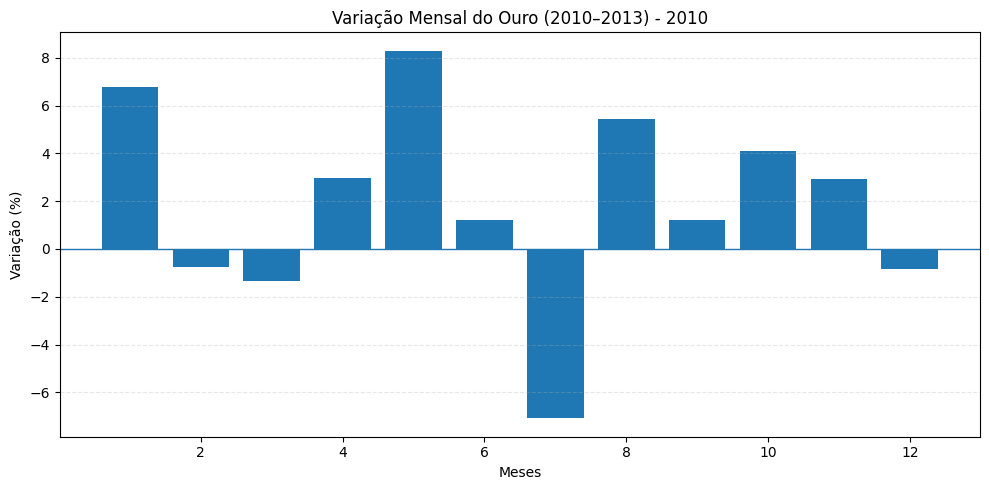

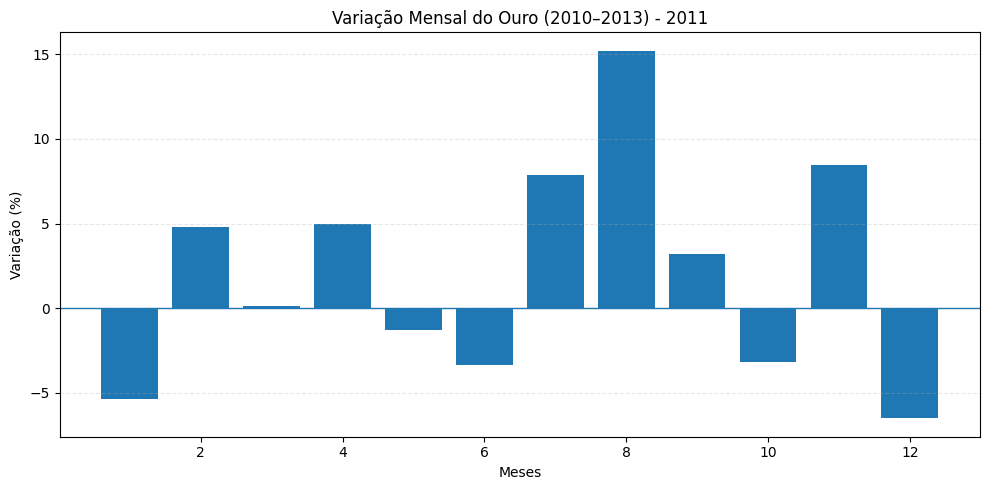

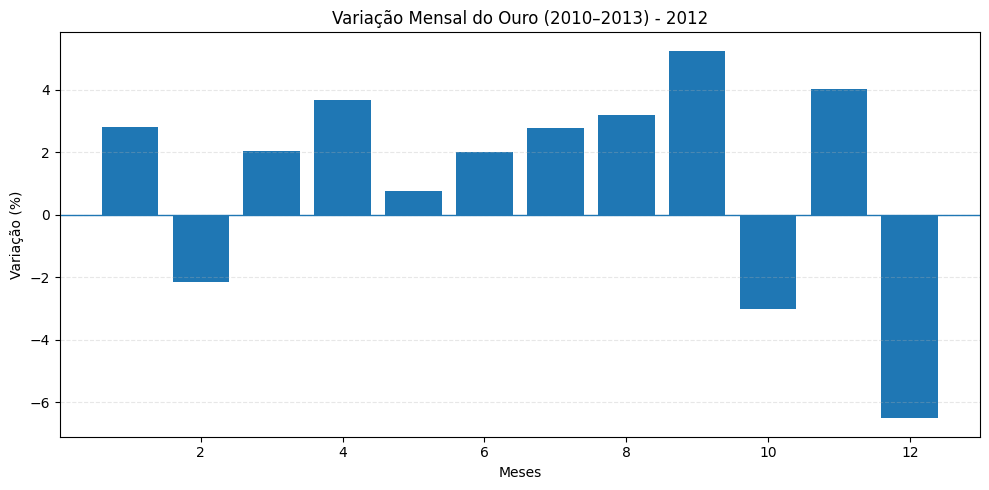

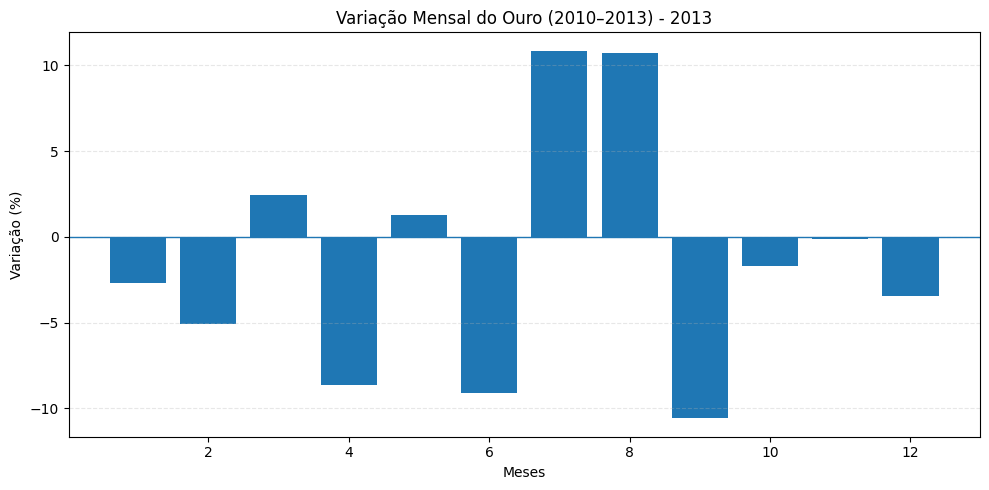

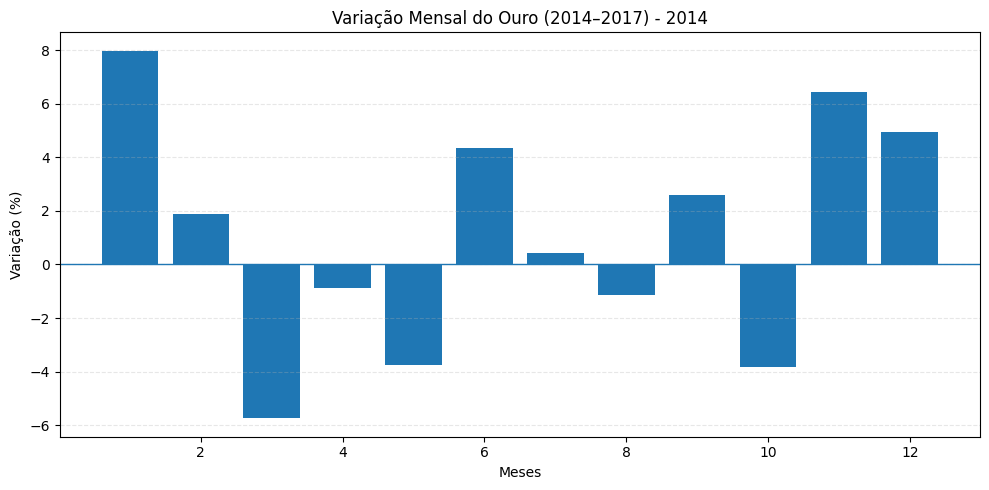

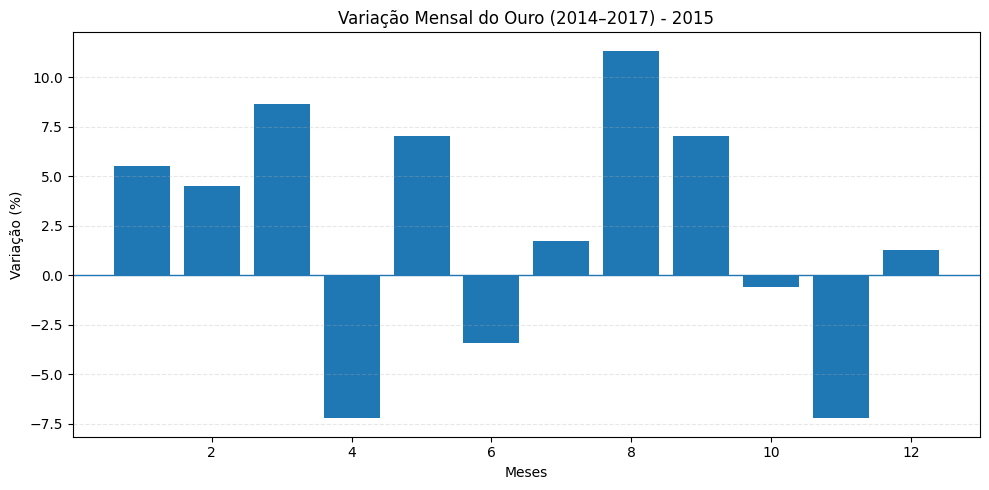

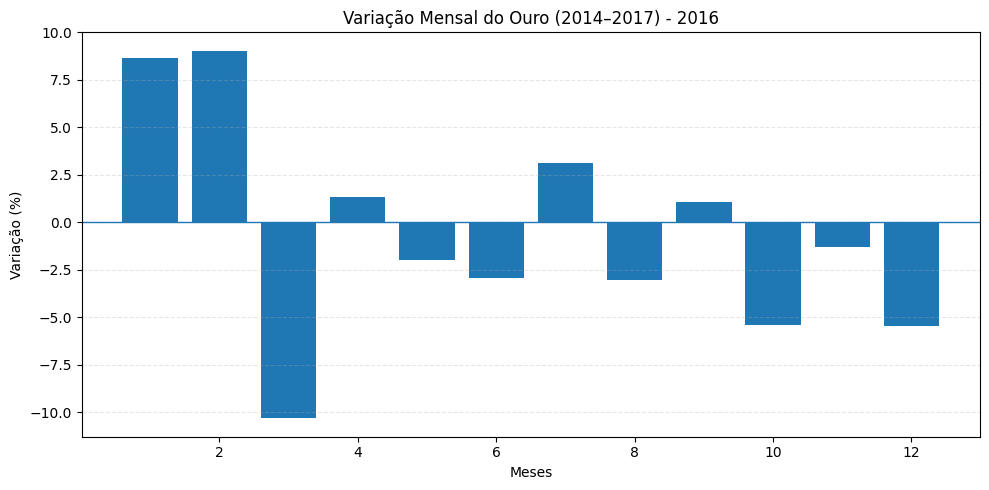

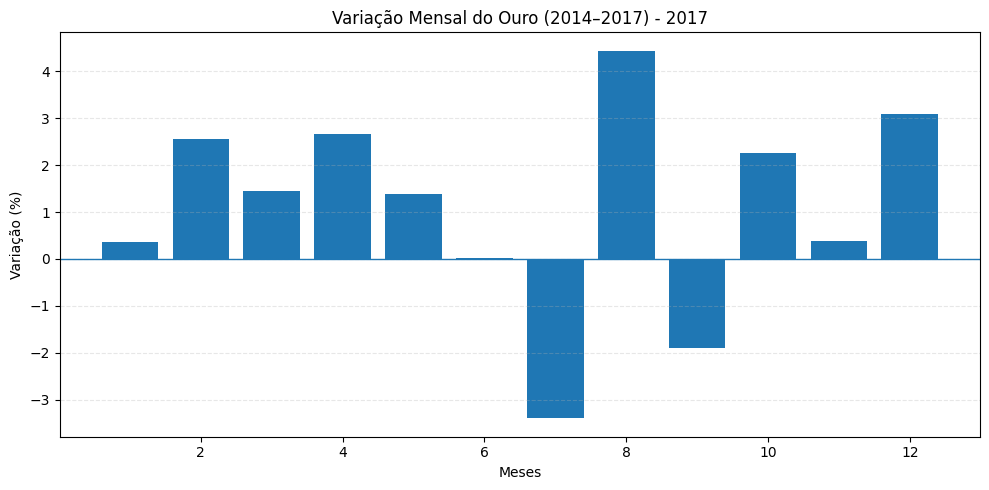

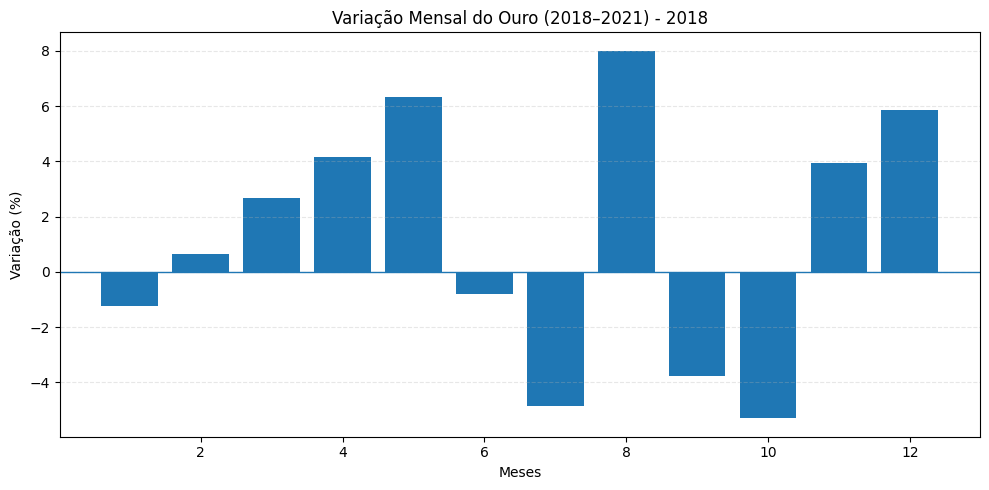

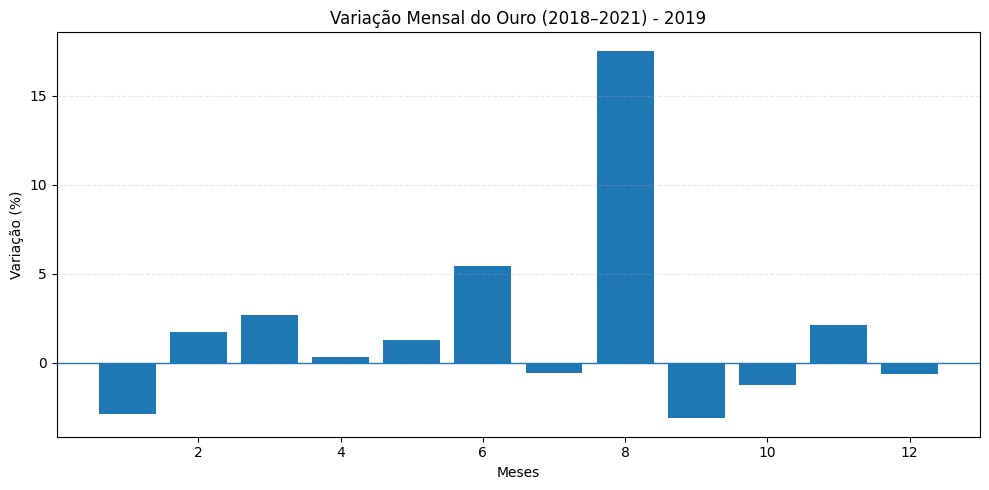

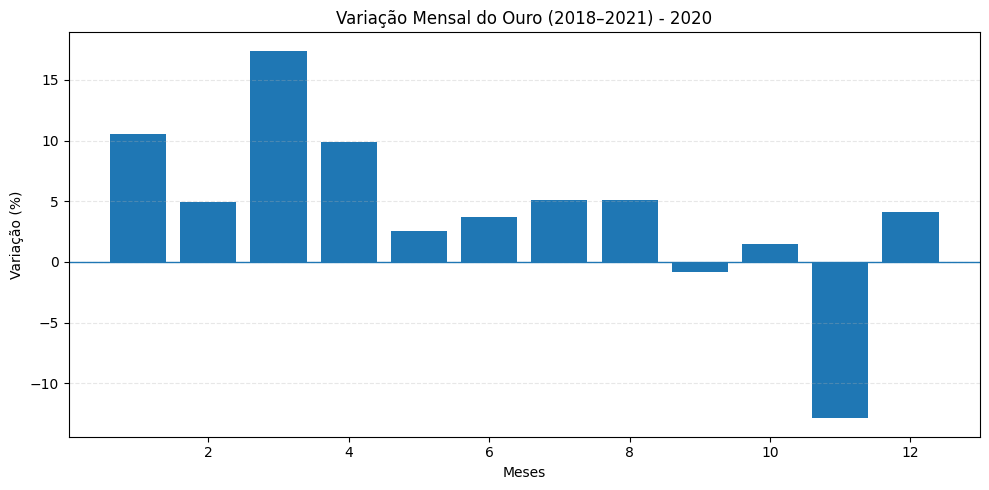

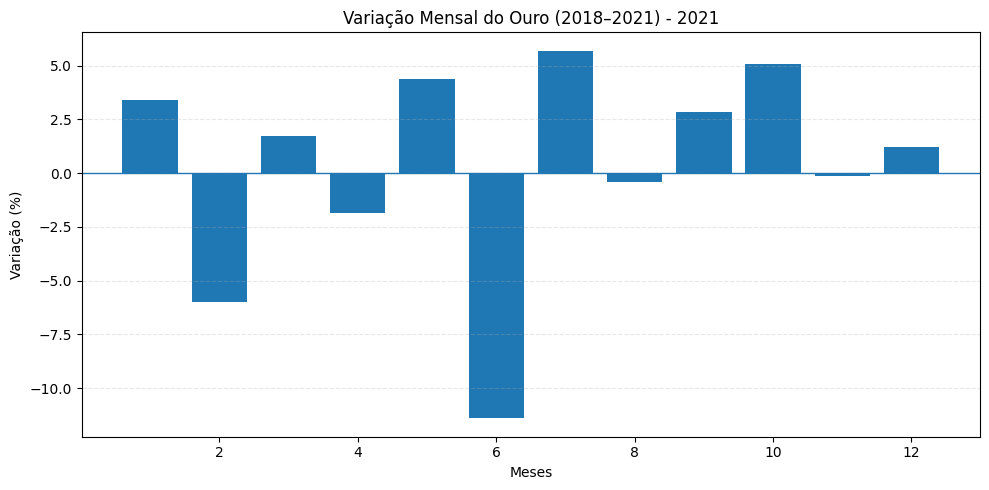

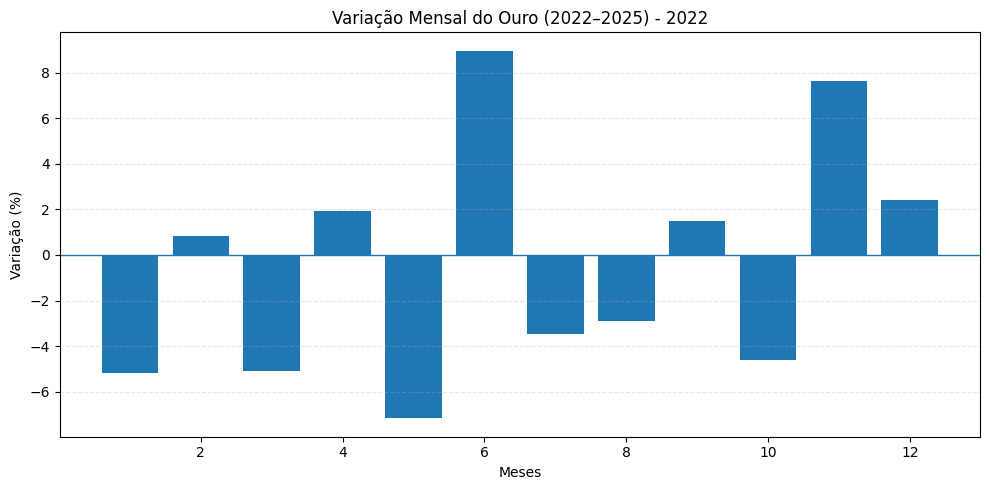

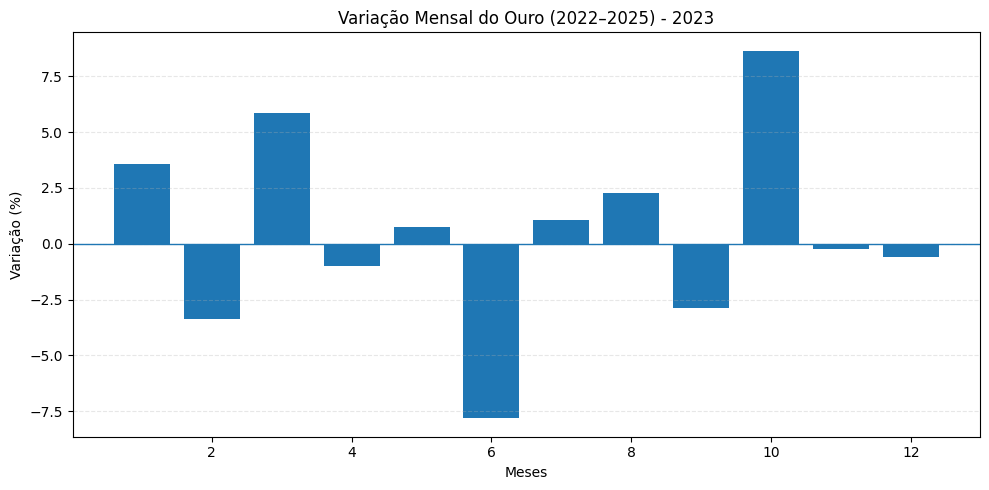

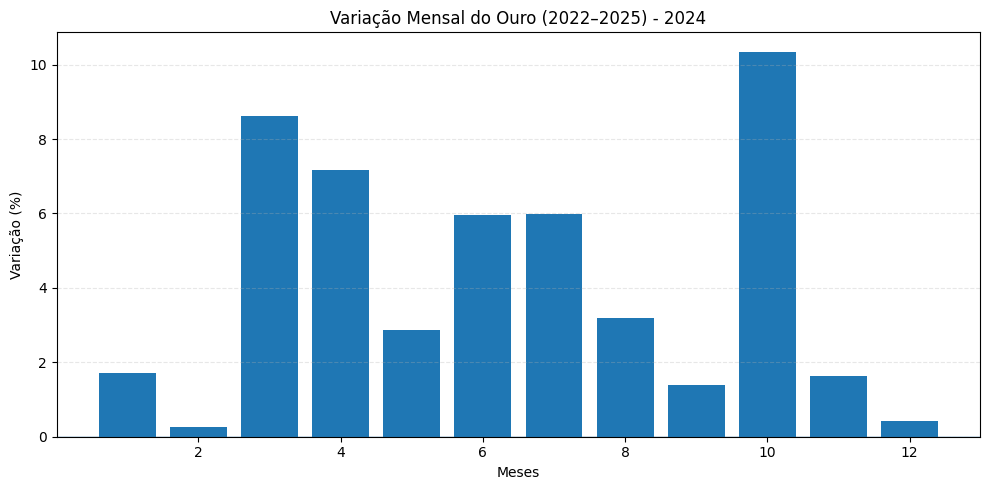

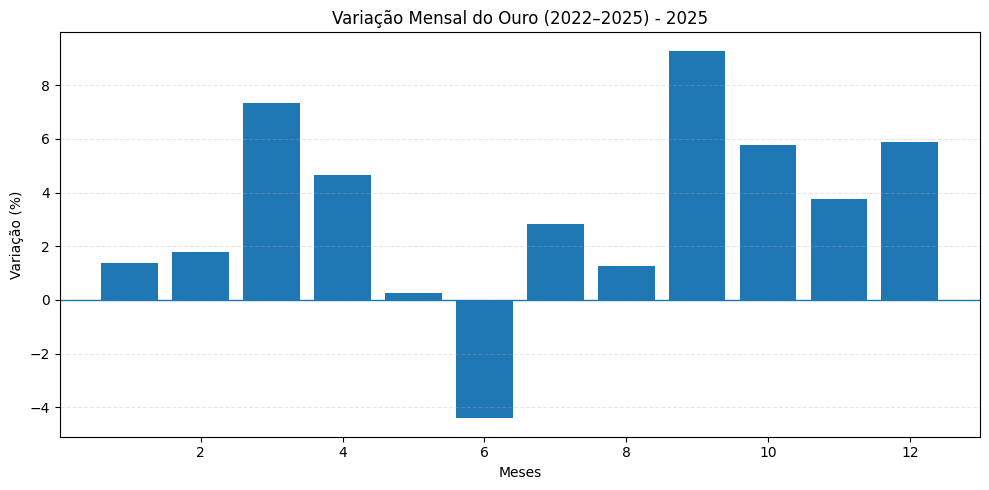

In [33]:
plotar_por_ano(tabela_1, 'Variação Mensal do Ouro (2010–2013)')
plotar_por_ano(tabela_2, 'Variação Mensal do Ouro (2014–2017)')
plotar_por_ano(tabela_3, 'Variação Mensal do Ouro (2018–2021)')
plotar_por_ano(tabela_4, 'Variação Mensal do Ouro (2022–2025)')


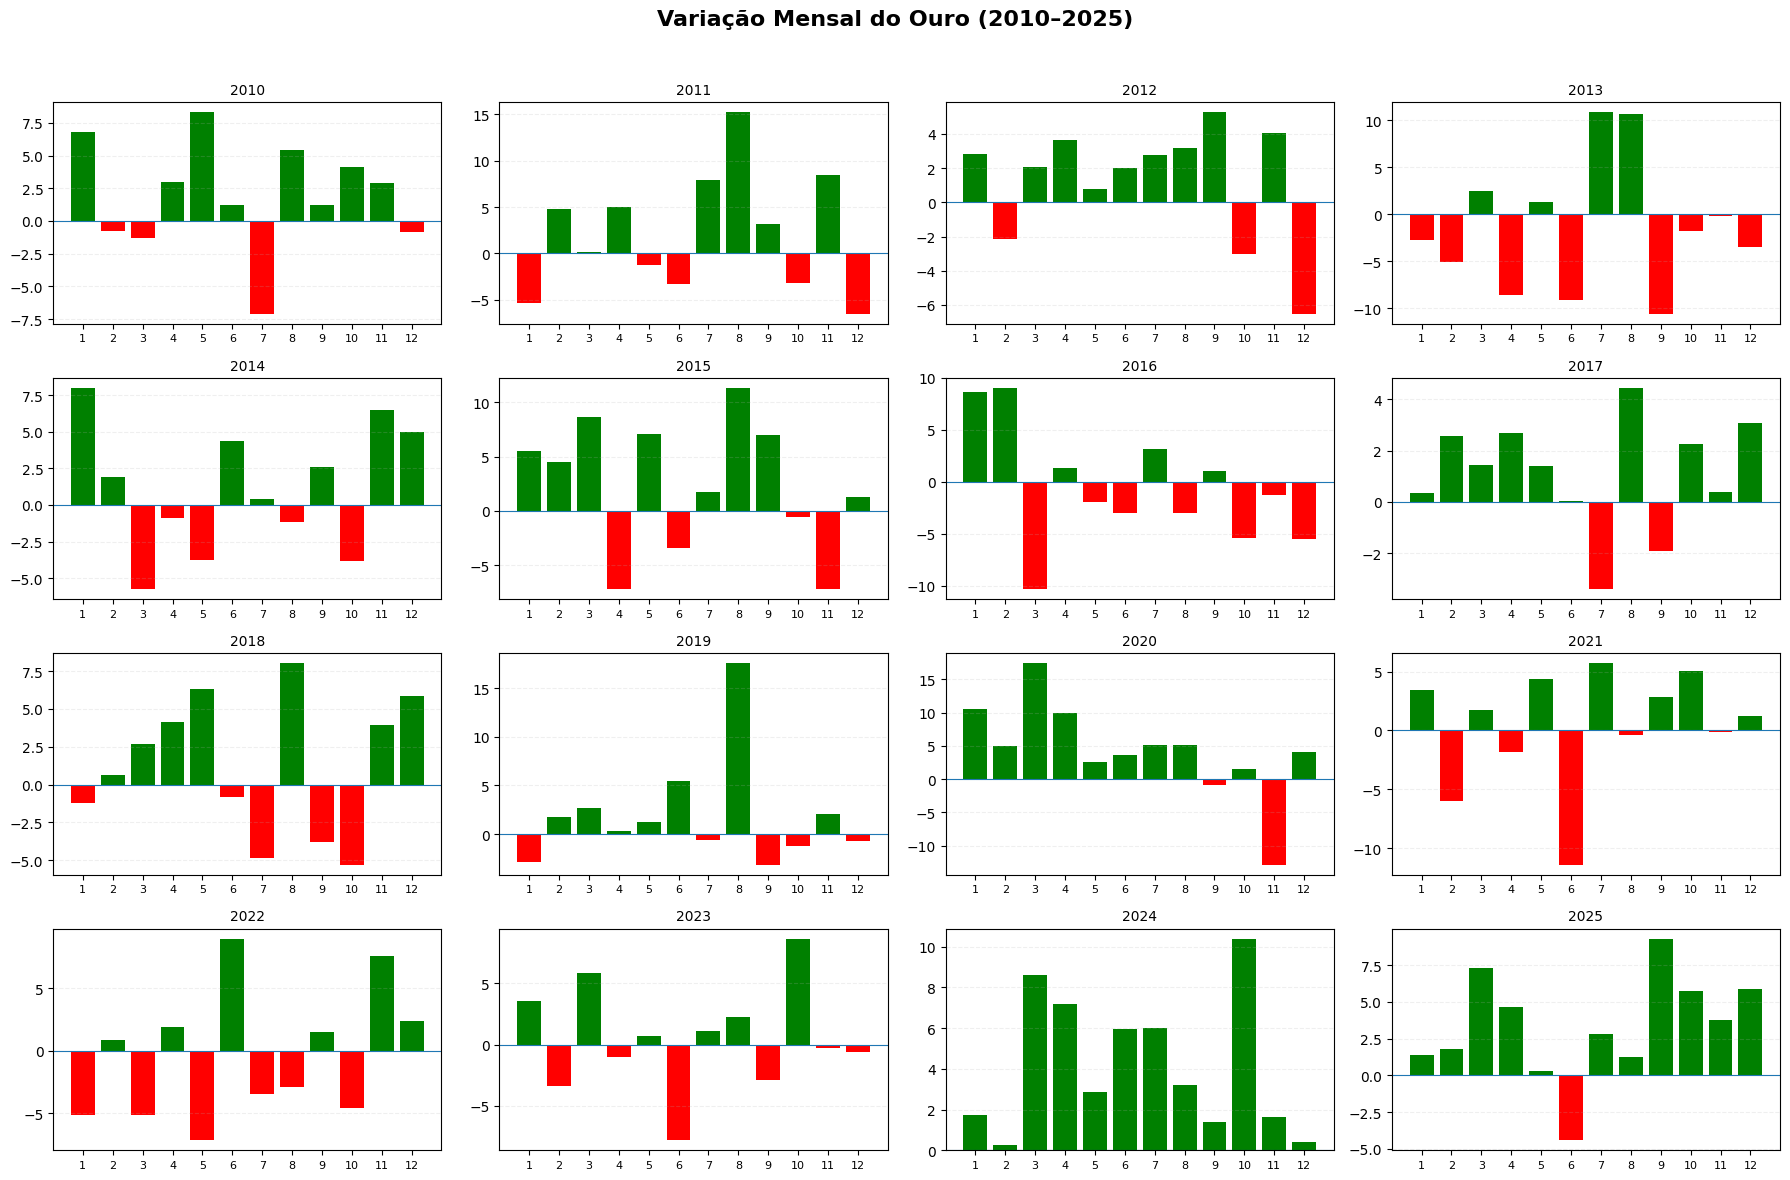

In [34]:
import matplotlib.pyplot as plt

# Juntar todas as tabelas
todas_tabelas = pd.concat([tabela_1, tabela_2, tabela_3, tabela_4])

# Garantir ordem dos anos
todas_tabelas = todas_tabelas.sort_index()

# Criar grid 4x4
fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, ano in enumerate(todas_tabelas.index):
    ax = axes[i]

    dados = todas_tabelas.loc[ano]

    # Cores: verde alta / vermelho queda
    cores = ['green' if v > 0 else 'red' for v in dados]

    ax.bar(dados.index, dados.values, color=cores)

    ax.set_title(str(ano), fontsize=10)
    ax.axhline(0, linewidth=0.8)
    ax.grid(axis='y', linestyle='--', alpha=0.2)

    # Melhorar leitura
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(range(1,13), fontsize=8)

# Ajustar layout
plt.suptitle('Variação Mensal do Ouro (2010–2025)', fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()
